In [41]:
import xarray as xr
import matplotlib.pyplot as plt
import cftime
import xclimate as xclim

In [ ]:
xclim.time_coord.shift_time

In [17]:
ARCH_DIR = "/glade/derecho/scratch/bbuchovecky/archive"
FSSP370_CASE = "f.e21.FSSP370_BGC.f19_f19_mg17.ssp370.coupPPE.000.test01"
FHIST_CASE = "f.e21.FHIST_BGC.f19_f19_mg17.historical.coupPPE.000"

In [20]:
xr.set_options(use_new_combine_kwarg_defaults=True)

atm_fhist = xr.open_mfdataset(f'{ARCH_DIR}/{FHIST_CASE}/atm/hist/{FHIST_CASE}.cam.h0.2014-*.nc', decode_timedelta=False)
lnd_fhist = xr.open_mfdataset(f'{ARCH_DIR}/{FHIST_CASE}/lnd/hist/{FHIST_CASE}.clm2.h0.2014-*.nc', decode_timedelta=False, join='outer')

atm_fssp = xr.open_mfdataset(f'{ARCH_DIR}/{FSSP370_CASE}/atm/hist/{FSSP370_CASE}.cam.h0.2015-*.nc', decode_timedelta=False)
lnd_fssp = xr.open_mfdataset(f'{ARCH_DIR}/{FSSP370_CASE}/lnd/hist/{FSSP370_CASE}.clm2.h0.2015-*.nc', decode_timedelta=False, join='outer')

In [28]:
atm = xclim.time_coord.shift_time(xr.concat([atm_fhist, atm_fssp], dim='time'))
lnd = xclim.time_coord.shift_time(xr.concat([lnd_fhist, lnd_fssp], dim='time'))

In [32]:
grid = xclim.load_fhist_ppe_grid().compute()

In [62]:
fhist = {}

for v in ['TREFHT', 'PRECL', 'PRECC']:
    fhist[v] = xclim.load_coupled_fhist_ppe(v, "atm", "month_1")[v].sel(member=0)

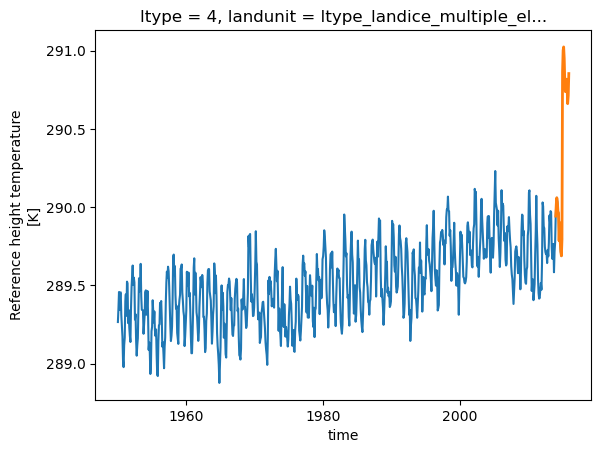

In [57]:
trefht['TREFHT'].weighted(grid.AREA.where(grid.LANDFRAC == 0, other=0)).mean(dim=['lat', 'lon']).plot()

atm['TREFHT'].weighted(grid.AREA.where(grid.LANDFRAC == 0, other=0)).mean(dim=['lat', 'lon']).plot(lw=2)
# plt.axvline(cftime.DatetimeNoLeap(2014, 12, 1, 0, 0, 0, 0, has_year_zero=True), c='k', lw=0.8)
# plt.axvline(cftime.DatetimeNoLeap(2015, 1, 1, 0, 0, 0, 0, has_year_zero=True), c='k', lw=0.8)

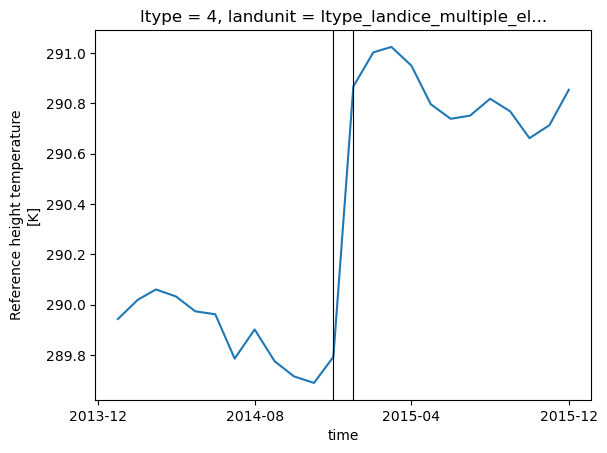

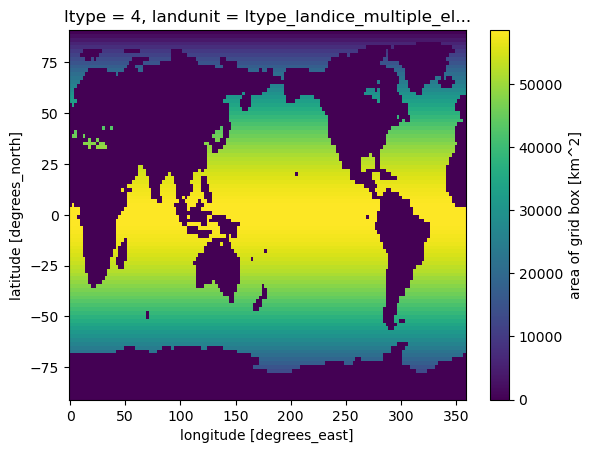

In [40]:
grid.AREA.where(grid.LANDFRAC == 0, other=0).plot()

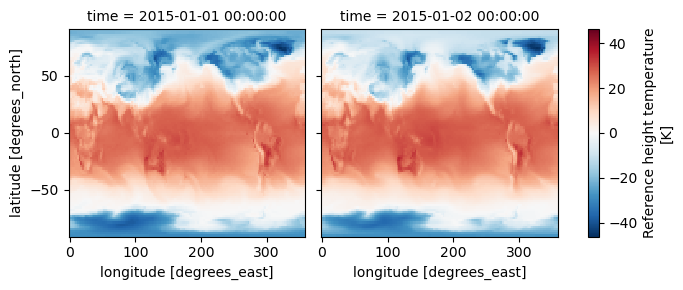

In [10]:
(atm.TREFHT - 273.15).plot(col='time')

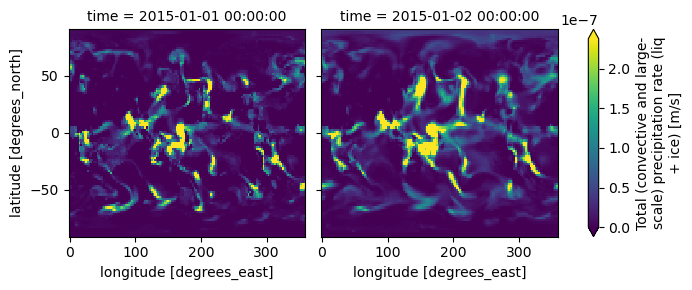

In [18]:
atm.PRECT.plot(col='time', robust=True)

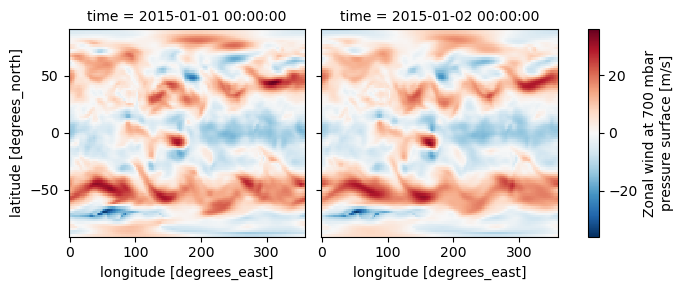

In [21]:
atm.U700.plot(col='time')

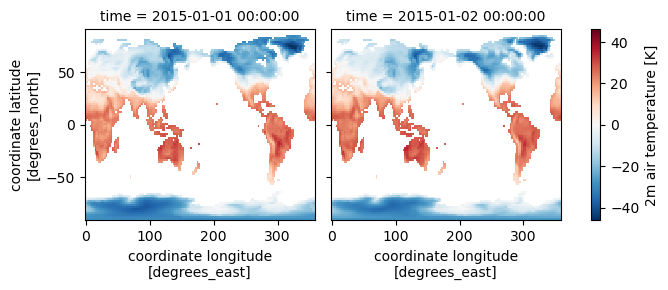

In [13]:
(lnd.TSA - 273.15).plot(col='time')

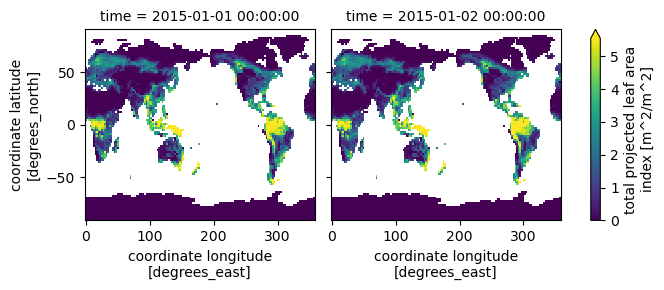

In [16]:
lnd.TLAI.plot(col='time', robust=True)

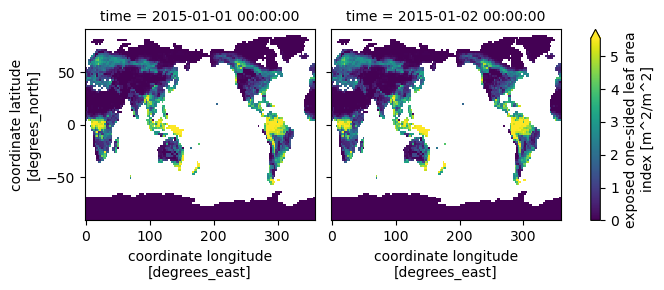

In [17]:
lnd.ELAI.plot(col='time', robust=True)